In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation
import scipy.io as sio
from scipy.sparse import csr_matrix
import os
import glob

sc.settings.set_figure_params(dpi=80, facecolor="white",  frameon=True)
sc.settings.verbosity = 2 # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.logging.print_header()

In [2]:
def read_scRNA_data(location:str, data_type:str, barcode_str=None):
    if data_type == "h5ad":
        try:
            adata = sc.read_h5ad(location)
            if not barcode_str == None:
                adata_barcode = [f'{barcode_str}_{ii}' for ii in range(adata.shape[0])]
                adata.obs_names = adata_barcode
            return adata
        except IsADirectoryError:
            print("""#####
            The input is not a file. Maybe it is a directory.
            Reading the first h5ad file in it.
            #####""")
            try:
                h5ad_files = glob.glob(location + "/*.h5ad")
                print(f"h5ad files: {h5ad_files[0]}")
                adata = sc.read_h5ad(h5ad_files[0]) #(location + '/' + h5ad_files[0])
                
                if not barcode_str == None:
                    adata_barcode = [f'{barcode_str}_{ii}' for ii in range(adata.shape[0])]
                    adata.obs_names = adata_barcode
                return adata
            except IndexError:
                print("There was no h5ad file to read.")
        except FileNotFoundError:
            print('The path to h5ad file seems incorrect.')
            
    if data_type == "mtx":
        print('Reading mtx')
        mtx_file = glob.glob(location + "/*.mtx")
        assert len(mtx_file)==1, 'There are more than one mtx file'
        gene_file = glob.glob(location + "/gene*")
        if len(gene_file)==0:
            gene_file = glob.glob(location + "/feat*")
        assert len(gene_file)==1, 'There are more than one gene name/id file'
        cluster_file = glob.glob(location + "/cluster*")

        adata = sc.read_mtx(mtx_file[0])
        adata= adata.T
        
        adata_features=pd.read_csv(gene_file[0], header=None, sep='\t')
        adata.var_names= adata_features[0].tolist()

        if len(cluster_file) == 1:
            leiden_clusters = pd.read_csv(cluster_file[0])
            adata.obs['leiden_precalculated'] = leiden_clusters['partition'].values
            adata.obs['leiden_precalculated'] = adata.obs['leiden_precalculated'].astype('category')

        if not barcode_str == None:
            adata_barcode = [f'{barcode_str}_{ii}' for ii in range(adata.shape[0])]
            adata.obs_names = adata_barcode

        return adata

In [3]:
adata1 = read_scRNA_data('br6471mid_real_5658x23973.h5ad', "h5ad", "br6471mid_real")

adata1

AnnData object with n_obs × n_vars = 5658 × 23973

In [4]:
adata2 = read_scRNA_data('br6471mid_gen_5657x23973.h5ad', "h5ad", "br6471mid_gen")

adata2

AnnData object with n_obs × n_vars = 5657 × 23973

In [5]:
adatas = {'br6471mid_real':adata1,'br6471mid_gen':adata2}

In [6]:
adata = ad.concat(adatas, label="dataset_name",  join="inner")

In [7]:
adata

AnnData object with n_obs × n_vars = 11315 × 23973
    obs: 'dataset_name'

In [8]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [9]:
adata.obs_names[0:10]

Index(['br6471mid_real_0', 'br6471mid_real_1', 'br6471mid_real_2',
       'br6471mid_real_3', 'br6471mid_real_4', 'br6471mid_real_5',
       'br6471mid_real_6', 'br6471mid_real_7', 'br6471mid_real_8',
       'br6471mid_real_9'],
      dtype='object')

In [10]:
adata.var_names[0:10]

Index(['DDX11L16', 'WASH7P', 'CICP27', 'WASH9P', 'LINC00115', 'MTND1P23',
       'MTND2P28', 'MTCO1P12', 'MTATP6P1', 'LINC01409'],
      dtype='object')

In [11]:
sum(adata.var_names.str.startswith("MT-")),sum(adata.var_names.str.startswith("mt-"))

(np.int64(37), np.int64(0))

In [12]:
# Quality Control
#######################
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL", ))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True, percent_top=[20]
)

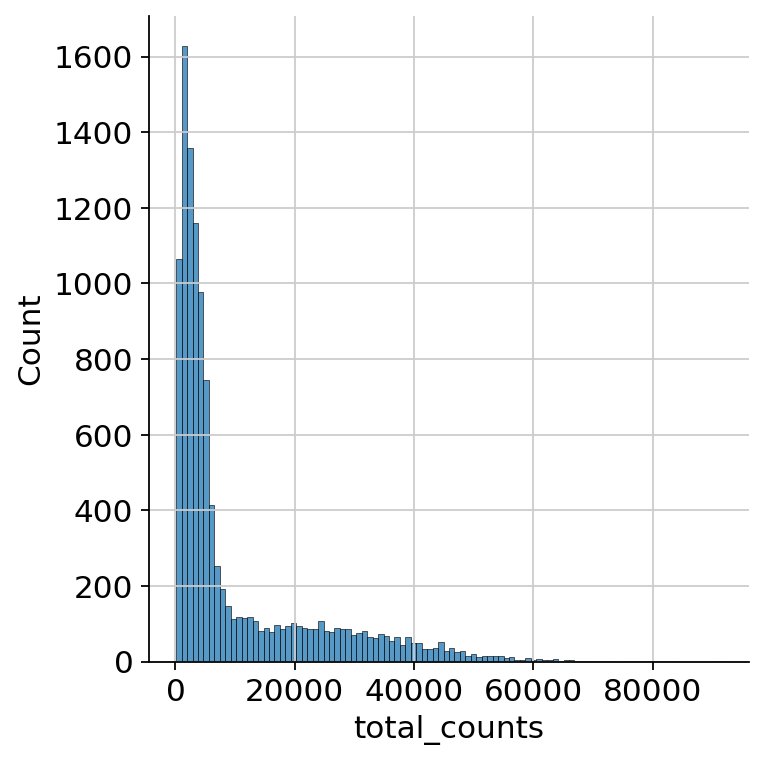

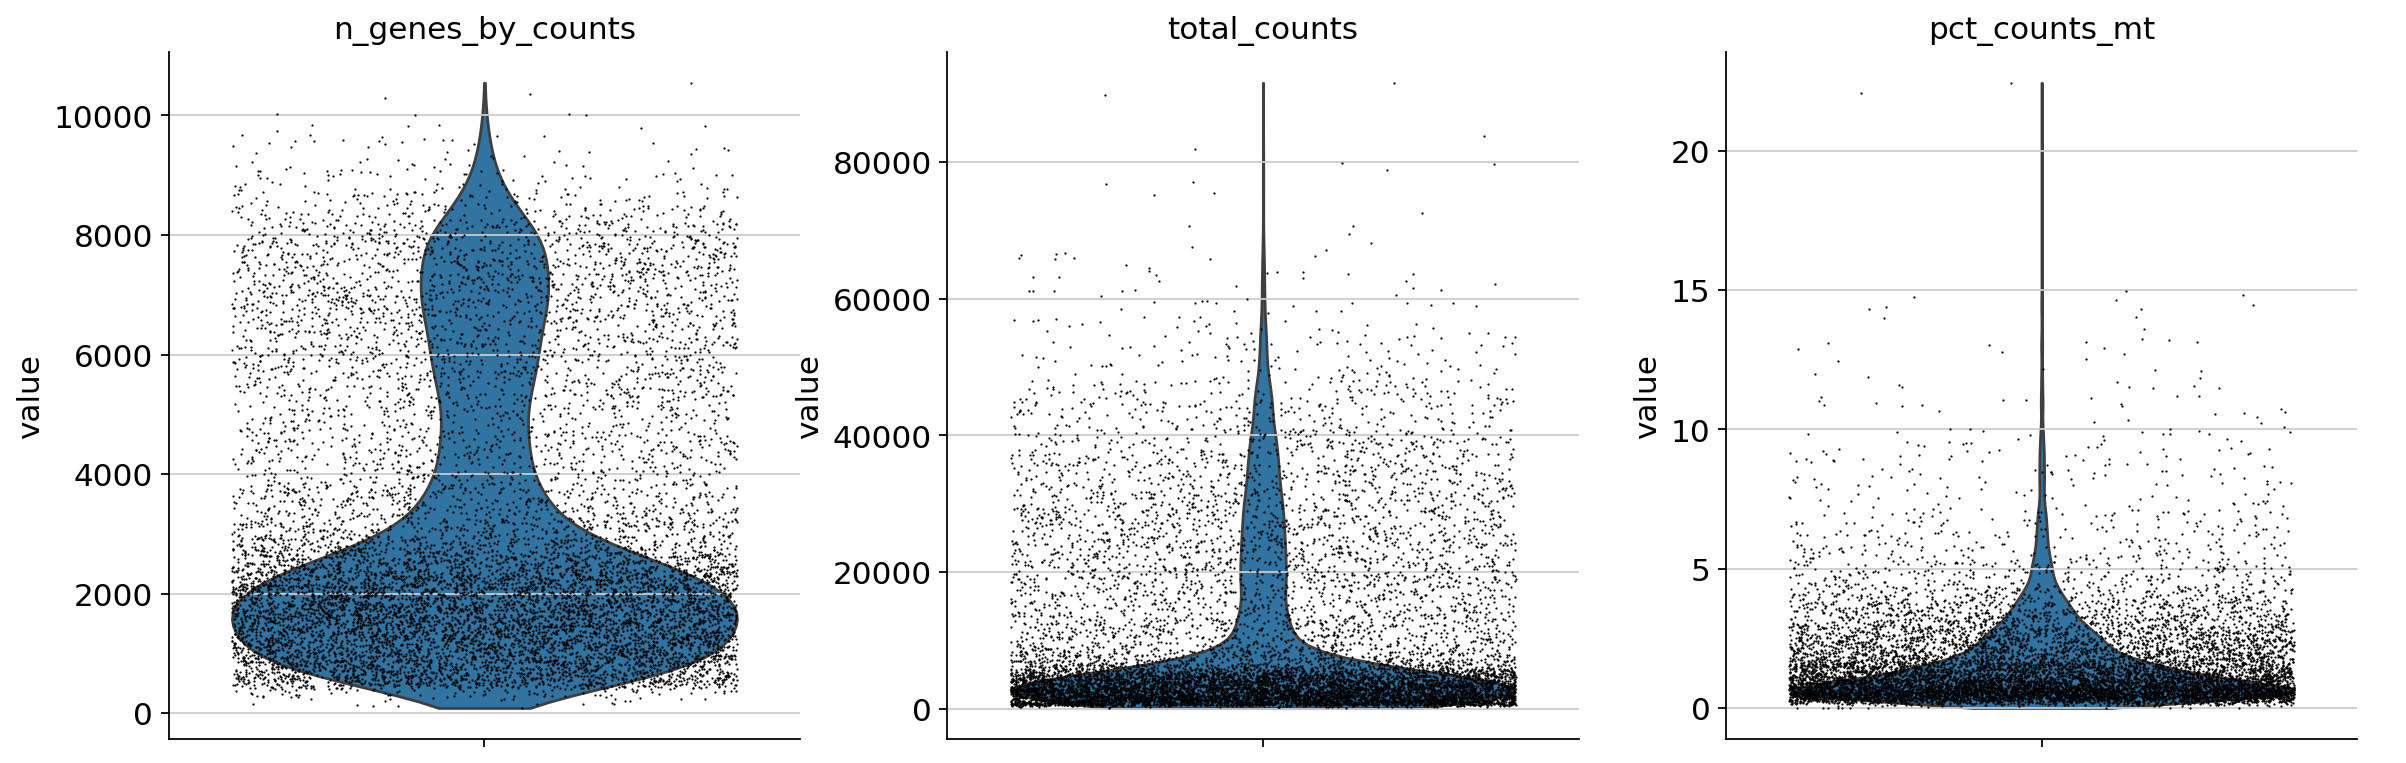

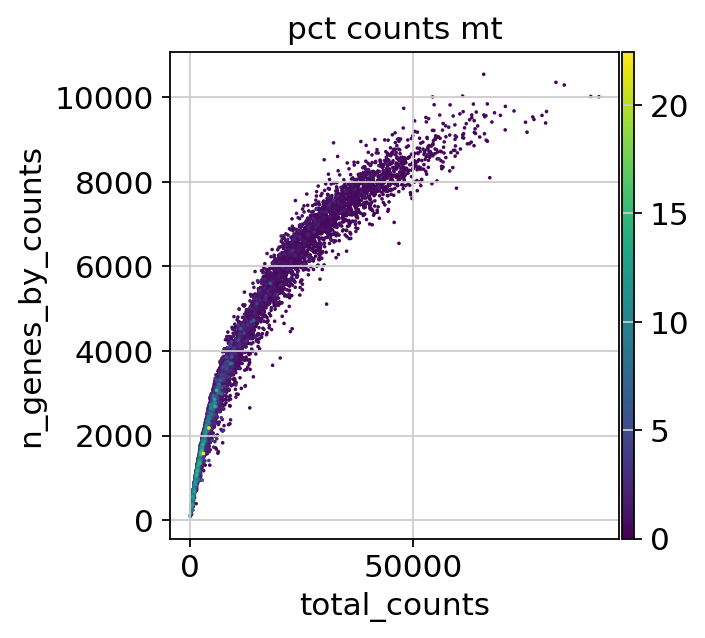

In [13]:
#https://www.sc-best-practices.org/
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
# p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [14]:
adata = adata[adata.obs["n_genes_by_counts"] < 18500]
adata = adata[adata.obs["n_genes_by_counts"] > 0]
# adata = adata[adata.obs["total_counts"] < 50000]
adata = adata[adata.obs["pct_counts_mt"] < 10]

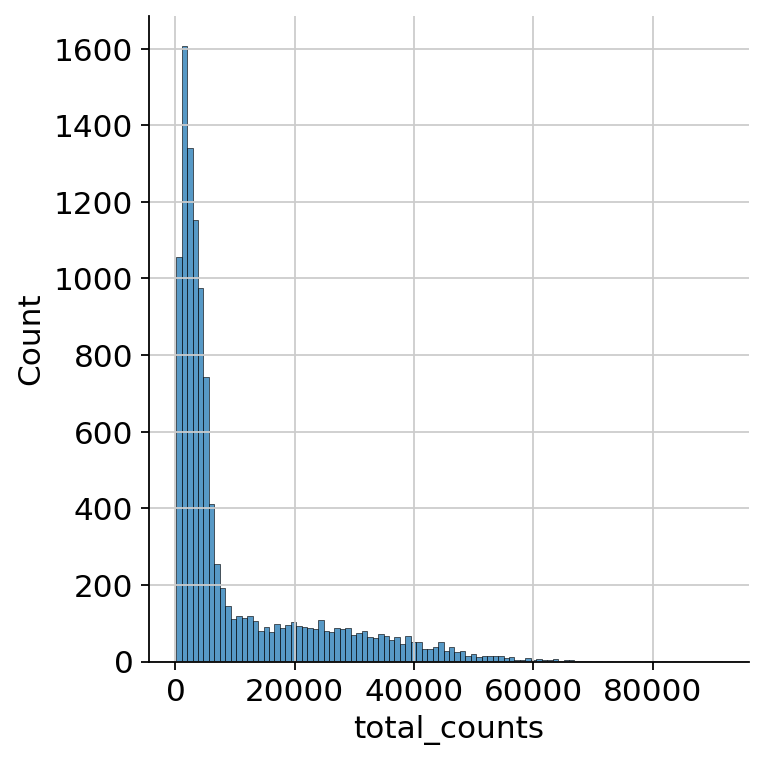

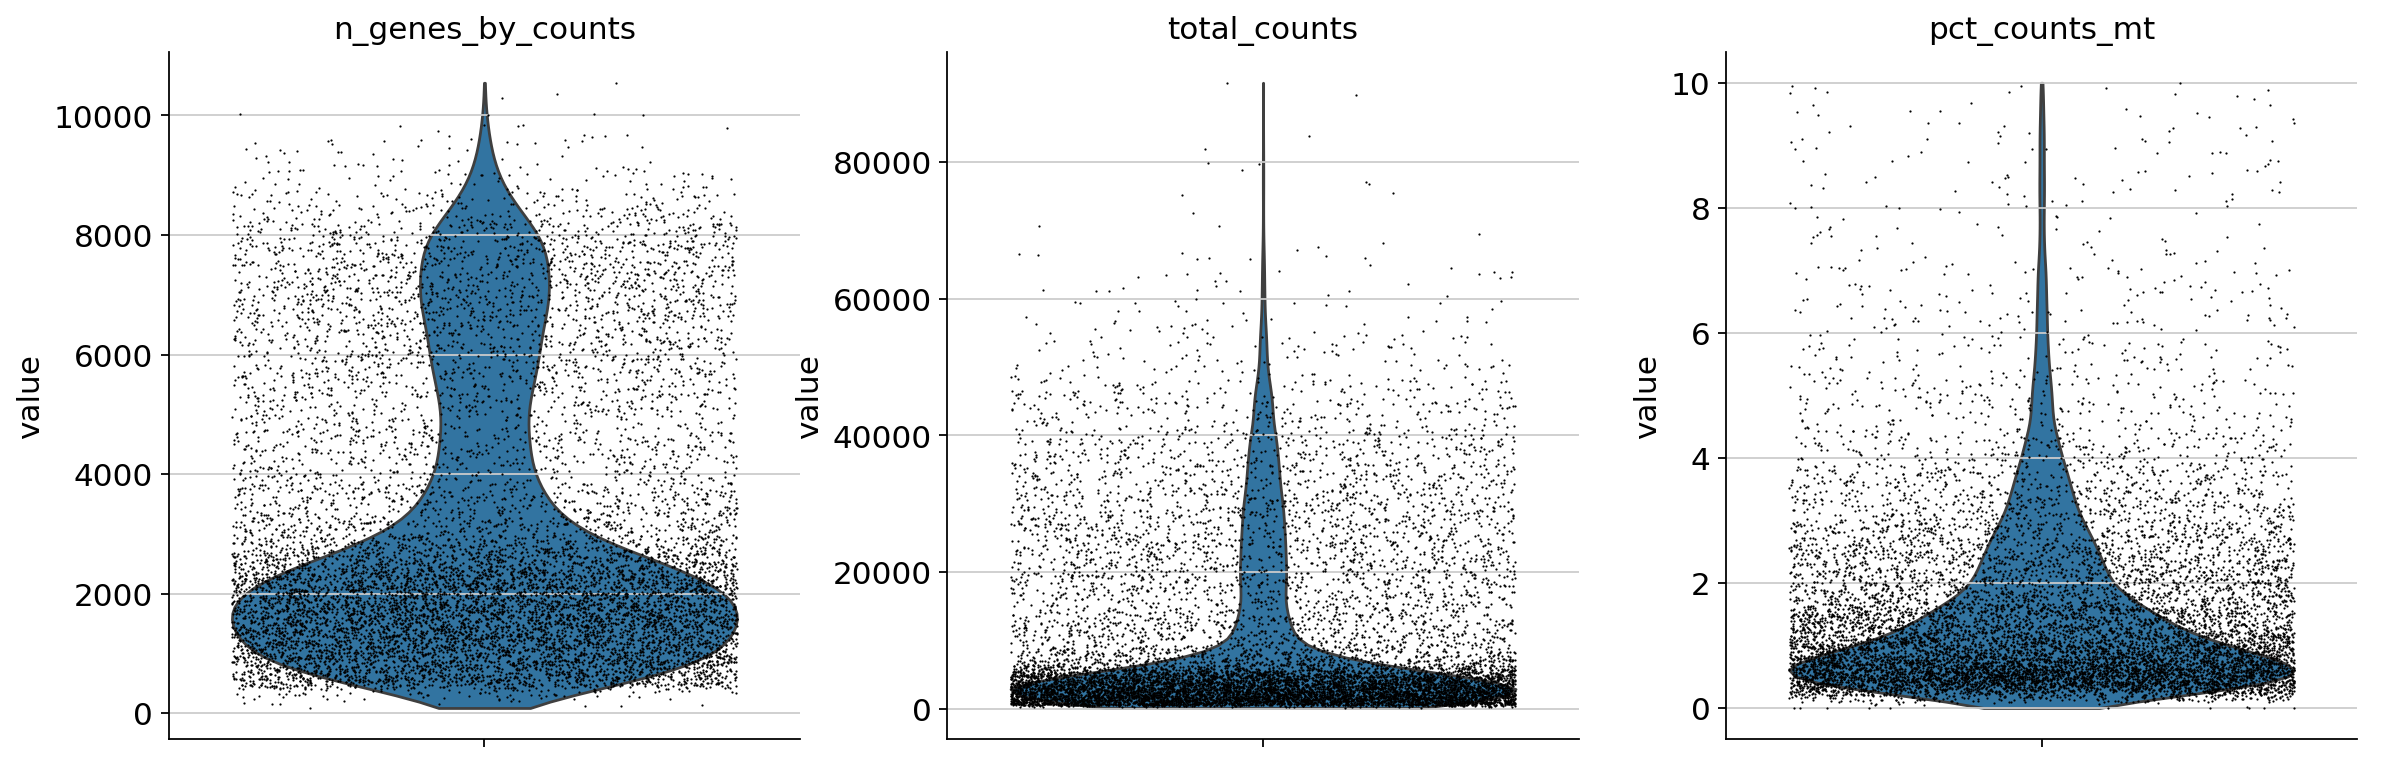

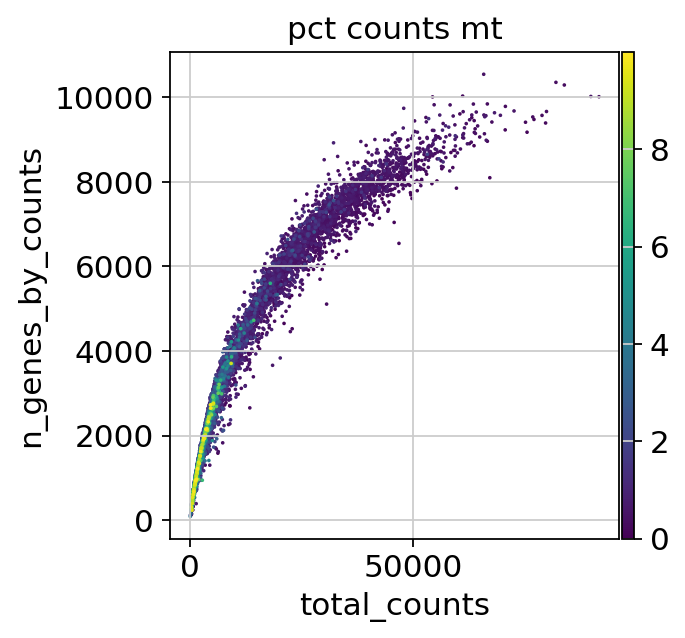

In [15]:
#https://www.sc-best-practices.org/
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
# p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [16]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

/tmp/ipykernel_799591/2262359327.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [17]:
# Normalizing to median total counts
# sc.pp.normalize_total(adata)
# normalize_total changes adata.X
sc.pp.normalize_total(adata, target_sum=None)#, inplace=False) 
# Logarithmize the data
# adata.X=log(adata.X+1)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [18]:
adata

AnnData object with n_obs × n_vars = 11252 × 23973
    obs: 'dataset_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'counts'

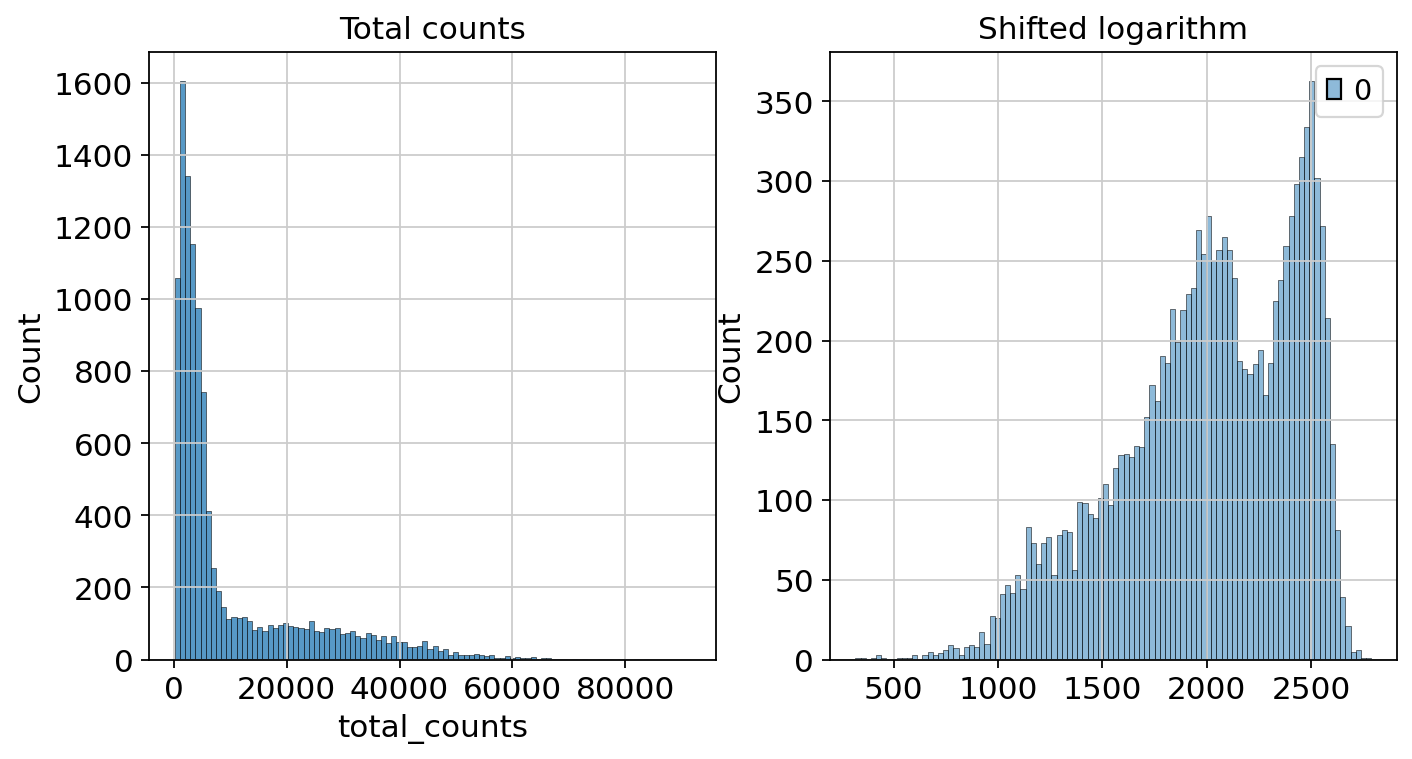

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.X.sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

extracting highly variable genes
    finished (0:00:00)


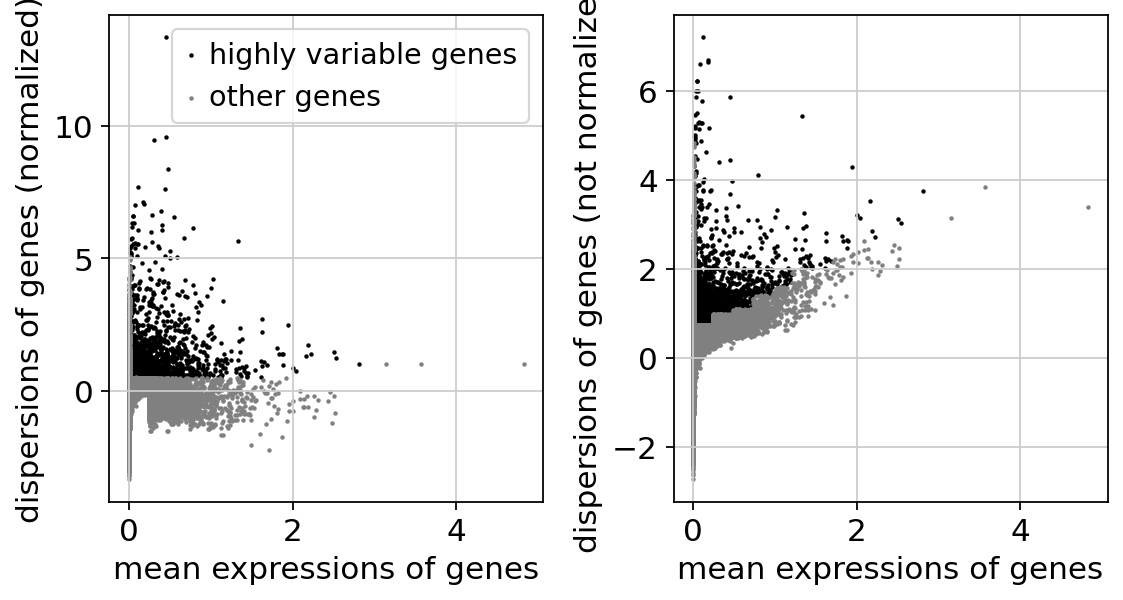

In [20]:
sc.pp.highly_variable_genes(adata)#, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

In [21]:
sc.tl.pca(adata)

computing PCA
    with n_comps=50
    finished (0:00:05)


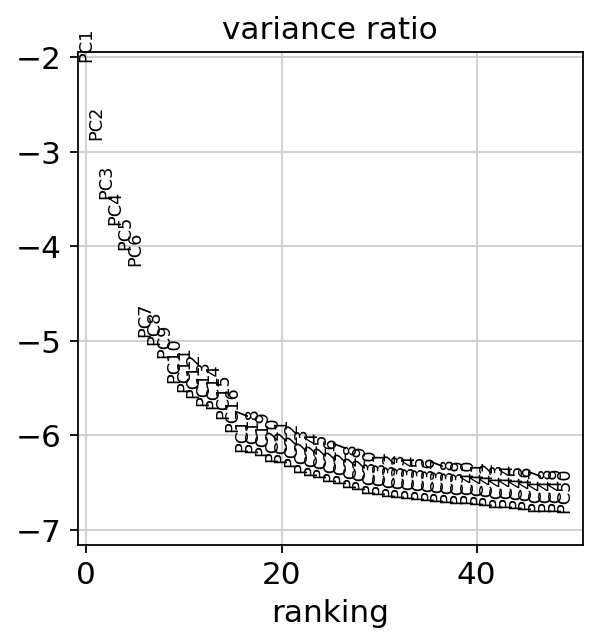

In [22]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

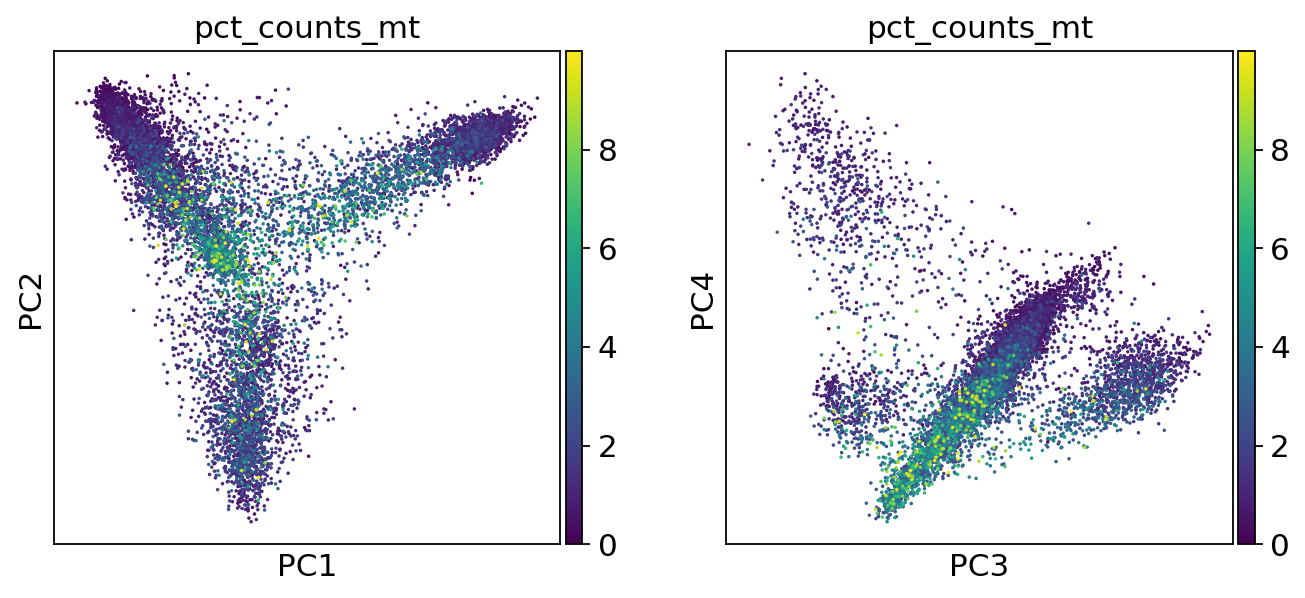

In [23]:
sc.pl.pca(
    adata,
    color=["pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=10,
)

In [24]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

computing neighbors
    using 'X_pca' with n_pcs = 50


/sfs/gpfs/tardis/project/iprime_storage/myles_kim/virtualenvs/torchenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-15 13:35:37.886738: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 13:35:39.516570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773596139.892482  799591 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773

    finished (0:01:00)


In [28]:
sc.tl.umap(adata, min_dist=0.2, random_state = 12344321)

computing UMAP
    finished (0:00:09)


In [26]:
adata

AnnData object with n_obs × n_vars = 11252 × 23973
    obs: 'dataset_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

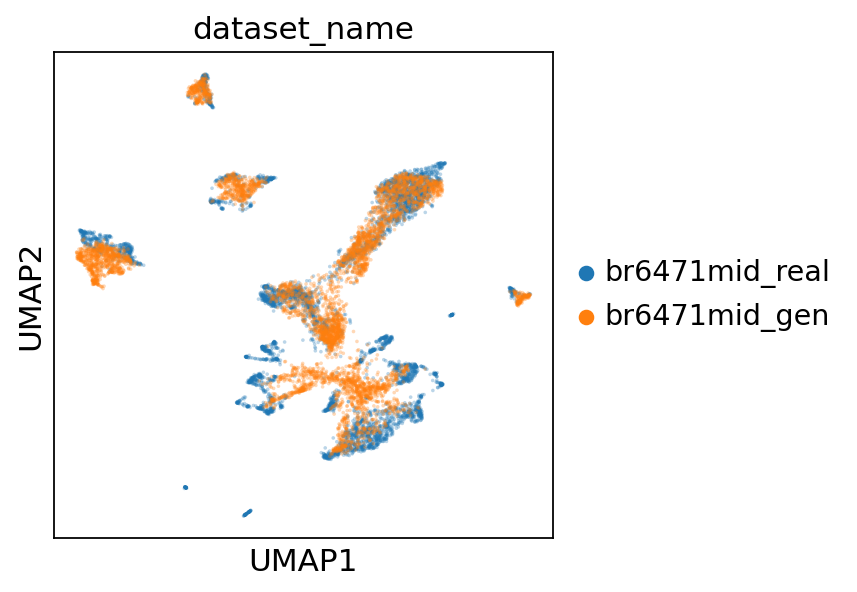

In [29]:
sc.pl.umap(adata, color=["dataset_name"], alpha=0.3, save='umap_original_gen.pdf')

In [30]:
# color dict
my_color25 = ['#e6194B','#3cb44b','#ffe119','#4363d8','#f58231',
              '#911eb4','#42d4f4','#f032e6','#adff2f','#469990', 
              '#000080','#9A6324','#800000','#808000','#2f4f4f', 
              '#7b68ee','#483d8b','#aaffc3','#cd853f','#005000',
              '#f5deb3','#ee82ee','#dcbeff','#a9a9a9','#000000']
cluster_list = [str(ii) for ii in range(25)]
cluster_list_num = [ii for ii in range(25)]
color25 = dict(zip(cluster_list, my_color25))
color25_num = dict(zip(cluster_list_num, my_color25))

In [31]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=100, resolution=0.7)

running Leiden clustering
    finished (0:00:10)


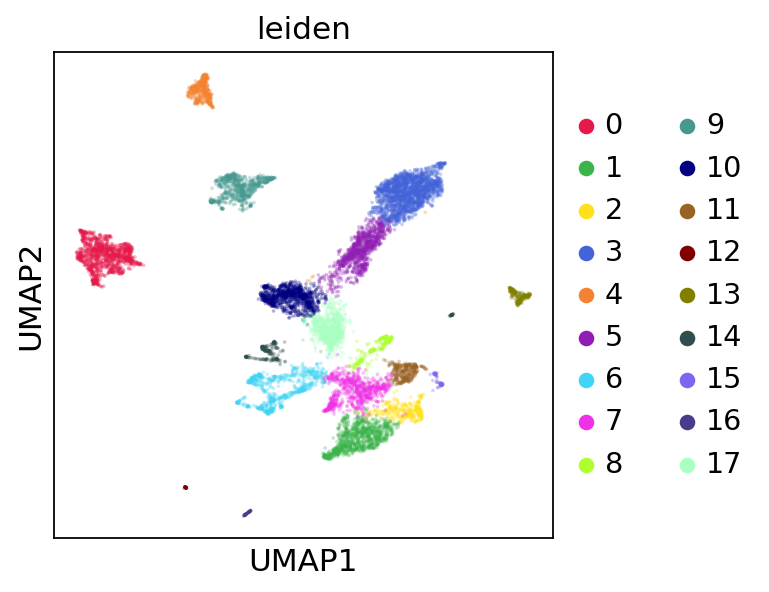

In [32]:
sc.pl.umap(adata, color=['leiden'], alpha=0.3, palette=color25)

/sfs/gpfs/tardis/project/iprime_storage/myles_kim/virtualenvs/torchenv/lib/python3.11/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


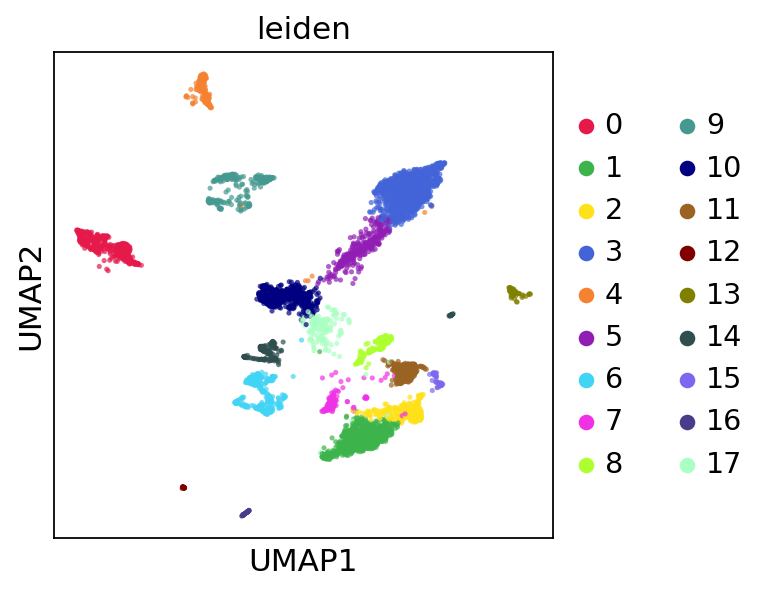

In [33]:
sc.pl.umap(adata[adata.obs['dataset_name']=='br6471mid_real',:], color=['leiden'], alpha=0.7, palette=color25, 
           save=f"_umap_for DGE_br6471mid_real.pdf")

/sfs/gpfs/tardis/project/iprime_storage/myles_kim/virtualenvs/torchenv/lib/python3.11/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


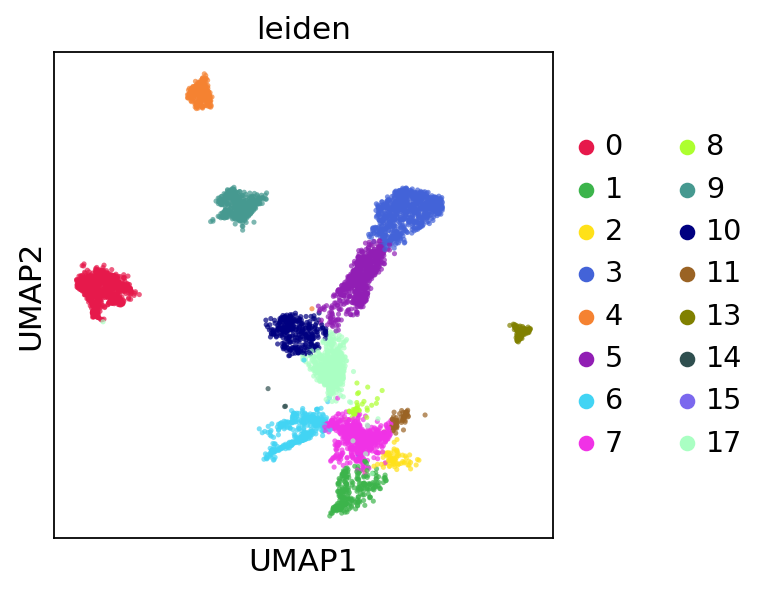

In [35]:
sc.pl.umap(adata[adata.obs['dataset_name']=='br6471mid_gen',:], color=['leiden'], alpha=0.7, palette=color25,
          save=f"_umap_for DGE_br6471mid_gen.pdf")

In [ ]:
adata.write_h5ad('adata_br6471mid_real_and_gen_for_monocle3.h5ad')

In [32]:
adata_br6471mid_real = adata[adata.obs['dataset_name']=='br6471mid_real',:]

In [ ]:
adata_br6471mid_real.write_h5ad('adata_br6471mid_real_for_monocle3.h5ad')

In [33]:
adata_br6471mid_gen = adata[adata.obs['dataset_name']=='br6471mid_gen',:]
# adata_br6471mid_gen.write_h5ad('adata_br6471mid_gen_for_monocle3.h5ad')

In [ ]:
adata.obs['leiden'][0]+1

In [ ]:
adata_minus_cl15 = adata[adata.obs['leiden']!='15',:]

In [ ]:
group_by=f'leiden'

sc.tl.rank_genes_groups(
    adata_minus_cl15, groupby=group_by, method="wilcoxon", key_added="dea_leiden"
)

sc.pl.rank_genes_groups(adata_minus_cl15, n_genes=25, sharey=False, key="dea_leiden", save=f"_top25_together.png")

In [ ]:
adata_br6471mid_real = adata_minus_cl15[adata_minus_cl15.obs['dataset_name']=='br6471mid_real',:]

In [ ]:
adata_br6471mid_real

ranking genes


/sfs/gpfs/tardis/project/iprime_storage/myles_kim/virtualenvs/torchenv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


    finished (0:00:02)


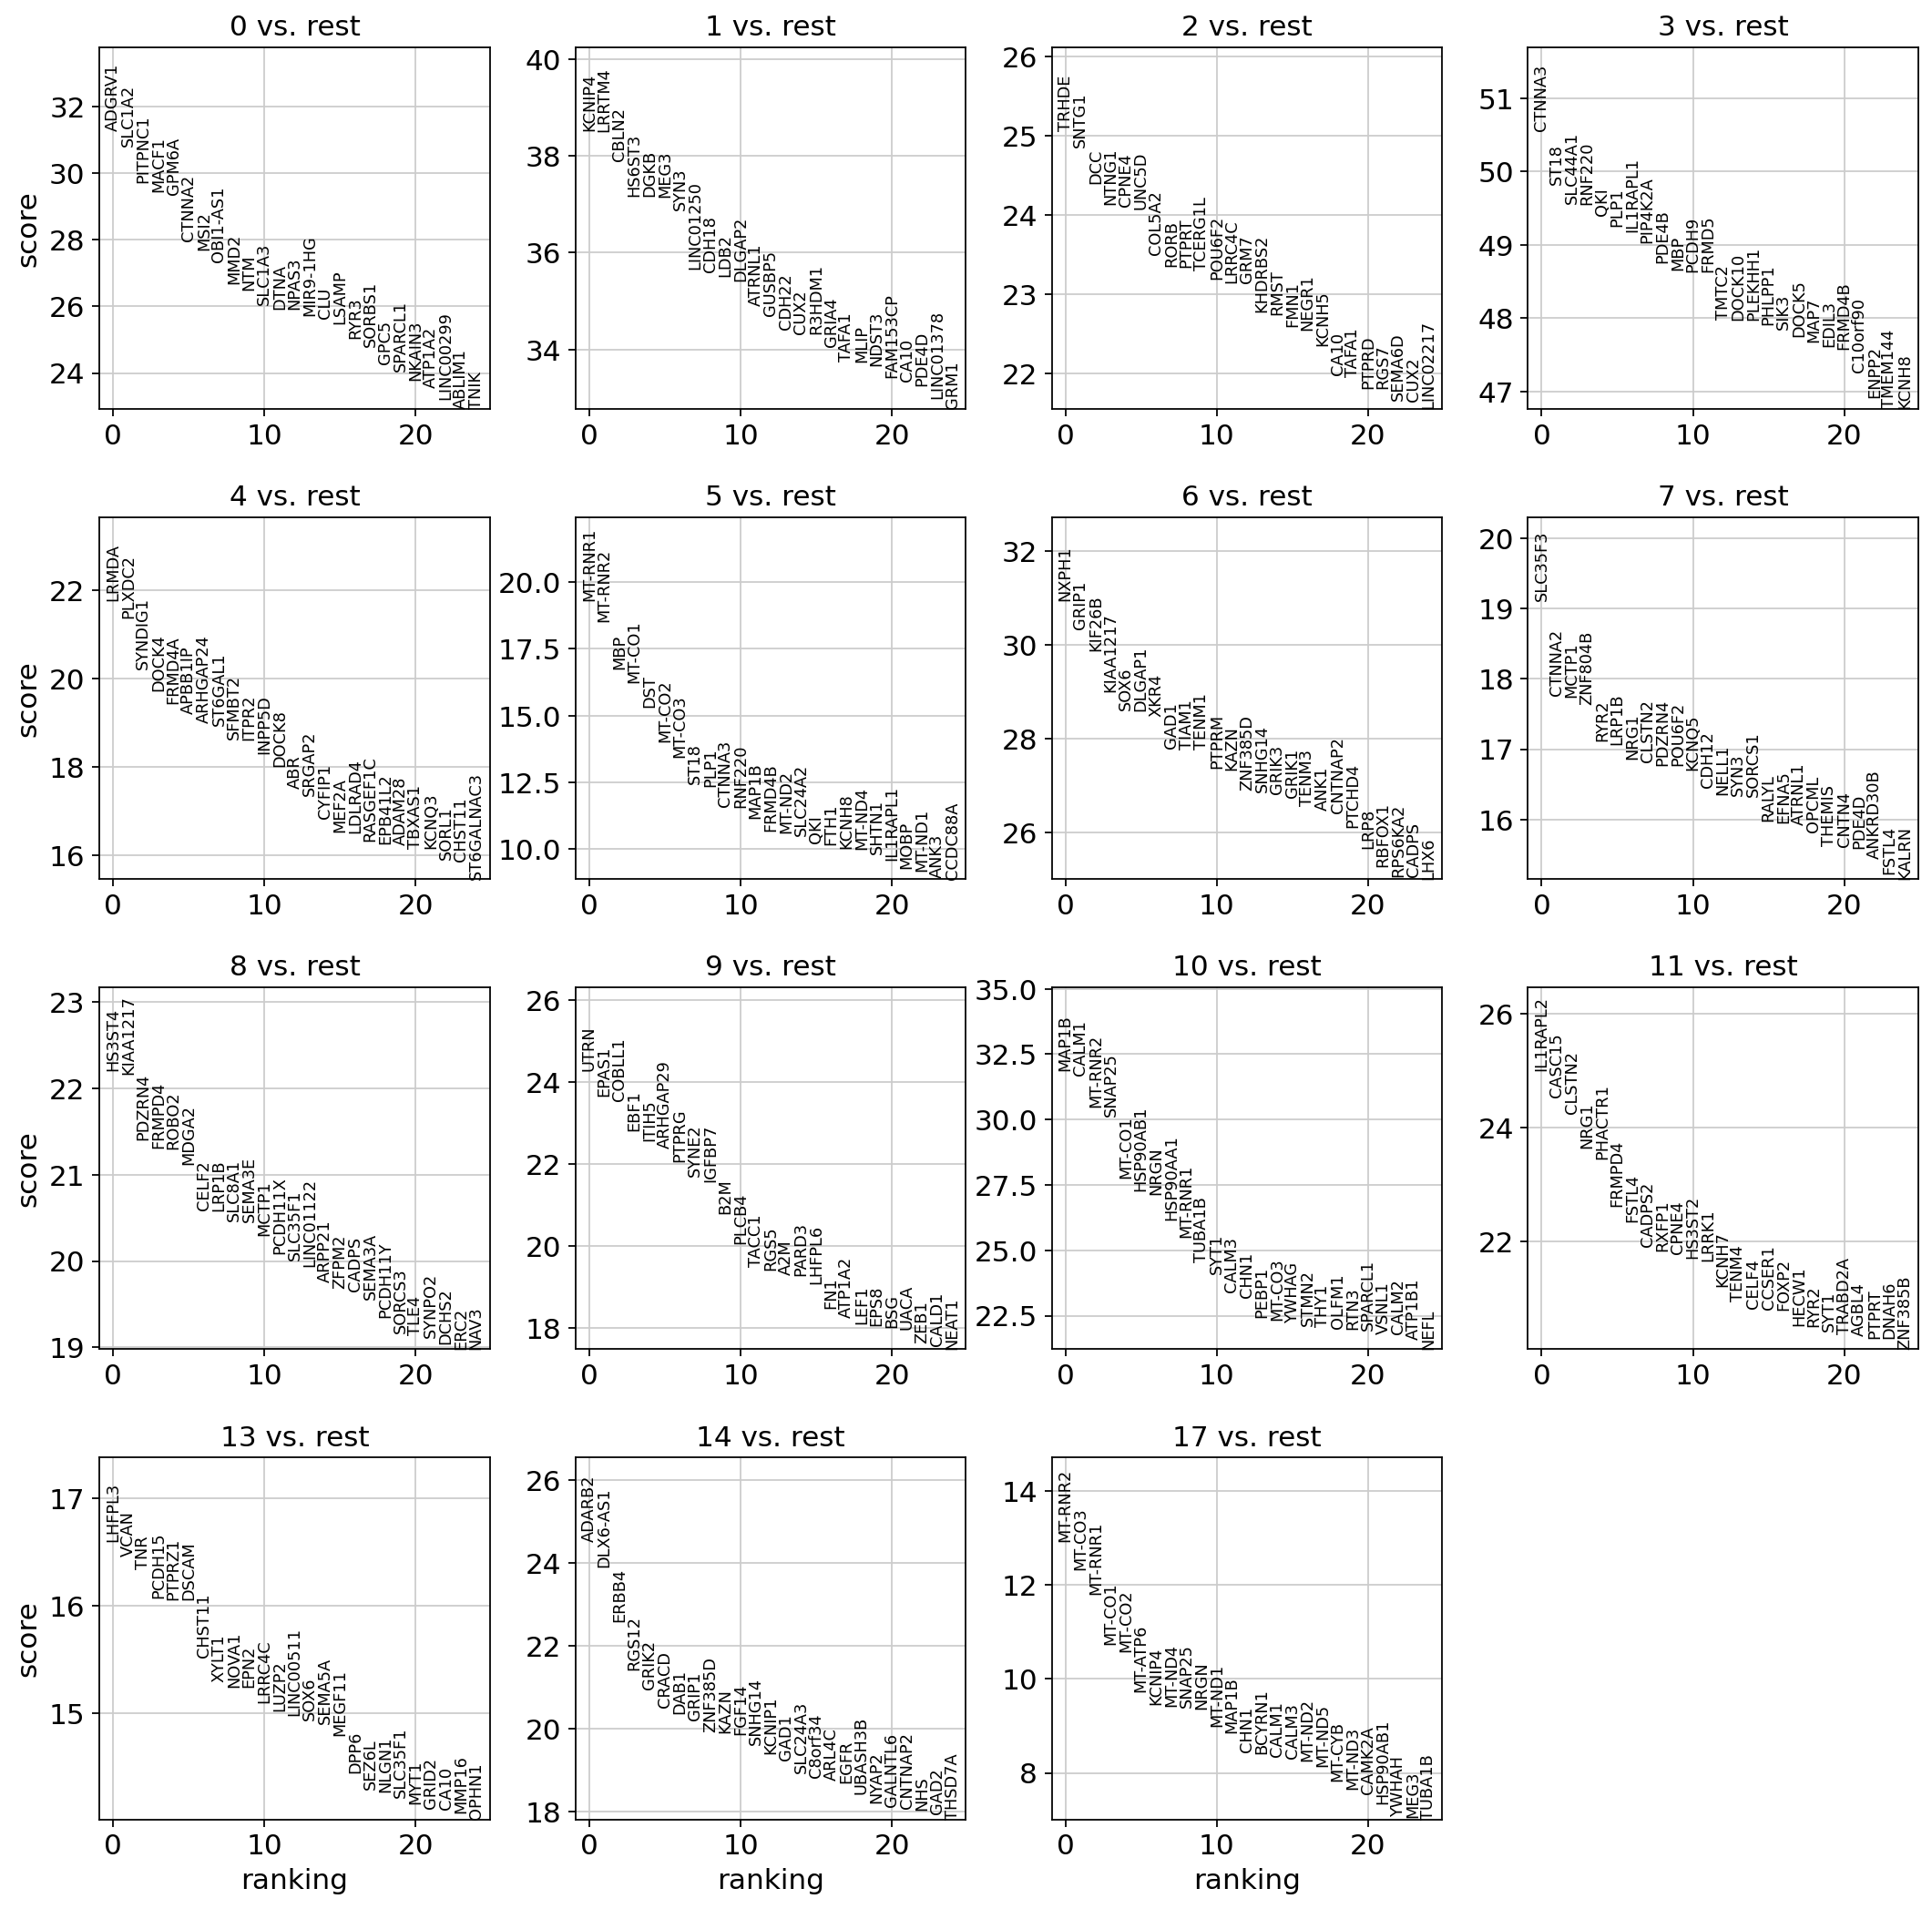

In [38]:
group_by=f'leiden'

sc.tl.rank_genes_groups(
    adata_br6471mid_real, groupby=group_by, method="wilcoxon", key_added="dea_leiden"
)

sc.pl.rank_genes_groups(adata_br6471mid_real, n_genes=25, sharey=False, key="dea_leiden", save=f"_top25_br6471mid_real.png")

In [ ]:
adata_br6471mid_gen = adata[adata.obs['dataset_name']=='br6471mid_gen',:]

In [ ]:
adata_br6471mid_gen.obs['leiden'].value_counts().sort_index()

In [ ]:
list(adata_br6471mid_gen.obs['leiden'].value_counts().sort_index().index)

In [34]:
cluster_2_use = ['0', '1',  '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '13', '14', '17']
adata_br6471mid_gen = adata_br6471mid_gen[adata_br6471mid_gen.obs['leiden'].isin(cluster_2_use),:]


In [ ]:
sc.pl.umap(adata_br6471mid_gen, color=['leiden'], alpha=0.7, palette=color25, save=f"_umap_for DGE_br6471mid_gen.pdf")

In [35]:
adata_br6471mid_real = adata[adata.obs['dataset_name']=='br6471mid_real',:]

In [36]:
adata_br6471mid_real = adata_br6471mid_real[adata_br6471mid_real.obs['leiden'].isin(cluster_2_use),:]

In [ ]:
sc.pl.umap(adata_br6471mid_real, color=['leiden'], alpha=0.7, palette=color25, save=f"_umap_for DGE_br6471mid_real.pdf")

In [ ]:
adata_br6471mid_gen = adata_minus_cl15[adata_minus_cl15.obs['dataset_name']=='br6471mid_gen',:]

In [ ]:
adata_br6471mid_gen

In [ ]:
# adata_br6471mid_gen.obs['leiden'].value_counts()

In [37]:
group_by=f'leiden'

sc.tl.rank_genes_groups(
    adata_br6471mid_gen, groupby=group_by, method="wilcoxon", key_added="dea_leiden"
)

# sc.pl.rank_genes_groups(adata_br6471mid_gen, n_genes=25, sharey=False, key="dea_leiden", save=f"_top25_br6471mid_gen.png")

ranking genes


/sfs/gpfs/tardis/project/iprime_storage/myles_kim/virtualenvs/torchenv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


    finished (0:00:02)


In [ ]:
adata_br6471mid_gen.uns['dea_leiden']

In [ ]:
df_dea_gen = sc.get.rank_genes_groups_df(adata_br6471mid_gen, group='3', key="dea_leiden")

# 2. Sort by group and significance for easy reading
# df_dea = df_dea.sort_values(['group', 'pvals_adj'])
df_dea_gen = df_dea_gen.sort_values(['pvals_adj'])

# 3. Save to a CSV file
# df_dea.to_csv("dea_results_leiden.csv", index=False)

# Display the first few rows
print(df_dea_gen.tail(50))

In [ ]:
# sc.pl.umap(adata, color=["leiden_precalculated"], alpha=0.5, palette=color25_num)

# sc.pl.umap(adata[adata.obs['dataset_name']=='br6471mid_real',:], color=["leiden_precalculated"], alpha=0.7, palette=color25_num)

# sc.pl.umap(adata[adata.obs['dataset_name']=='br6471mid_gen',:], color=["leiden_precalculated"], alpha=0.7, palette=color25_num)

In [ ]:
df_dea_gen.shape

In [ ]:
df_dea_gen_sig = df_dea_gen.loc[df_dea_gen['pvals_adj']<0.05,:]

In [ ]:
df_dea_gen_sig.shape

In [ ]:
df_dea_real = sc.get.rank_genes_groups_df(adata_br6471mid_real, group='3', key="dea_leiden")

# 2. Sort by group and significance for easy reading
# df_dea = df_dea.sort_values(['group', 'pvals_adj'])
df_dea_real = df_dea_real.sort_values(['pvals_adj'])

# 3. Save to a CSV file
# df_dea.to_csv("dea_results_leiden.csv", index=False)

# Display the first few rows
print(df_dea_real.head(10))

In [ ]:
df_dea_real.shape

In [ ]:
df_dea_real_sig = df_dea_real.loc[df_dea_real['pvals_adj']<0.05,:]

In [ ]:
df_dea_real_sig.shape

In [ ]:
df_dea_real_sig.tail()

In [ ]:
gen_sig_set = set(df_dea_gen_sig.names)

In [ ]:
real_sig_set = set(df_dea_real_sig.names)

In [ ]:
set_inter = real_sig_set.intersection(gen_sig_set)

In [ ]:
len(set_inter)

In [ ]:
df_dea_gen_sig.tail()

In [ ]:
set1 = set(df_dea_real_sig['names'][0:100])

In [ ]:
set2 = set(df_dea_gen_sig['names'][0:100])

In [ ]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

In [ ]:
kk = 1000
group_n = 12
gen_3 = adata_br6471mid_gen.uns['dea_leiden']['names'][str(group_n)]
real_3 = adata_br6471mid_real.uns['dea_leiden']['names'][str(group_n)]

venn2([set(gen_3[0:kk]), set(real_3[0:kk])], set_labels=('Generated', 'Real'))
plt.title(f"Top {kk} sigmificant gene overlap. cluster {group_n} vs rest\n(DLPFC Sample BR6471mid)")

In [ ]:
adata_br6471mid_real.obs['leiden'].value_counts().sort_index()

In [ ]:
temp = adata_br6471mid_gen.obs['leiden'].value_counts().sort_index()

In [ ]:
len(list(temp.index))

In [ ]:
adata_br6471mid_gen.shape[1]

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
kk=1000
# 1. Setup the figure: 3 rows, 5 columns
fig, axes = plt.subplots(3, 5, figsize=(20, 13))
axes_flat = axes.flatten()  # Converts 3x5 matrix into a list of 15

# 2. Iterate through your clusters (adjust the range or list as needed)
# Assuming you have 15 clusters to compare
for i in range(15):
    ax = axes_flat[i]
    
    # Replace these with your actual gene set extraction logic
    # Example: gen_set = set(df_dea[df_dea['group'] == str(i)]['names'])
    set_a = adata_br6471mid_gen.uns['dea_leiden']['names'][list(temp.index)[i]]
    set_b = adata_br6471mid_real.uns['dea_leiden']['names'][list(temp.index)[i]]
    
    # if set_a or set_b:
    M = adata_br6471mid_gen.shape[1]
    N = kk
    n = kk
    x = venn2([set(set_a[0:kk]), set(set_b[0:kk])], 
              set_labels=('Generated', 'Real'), ax=ax).get_label_by_id('11').get_text()
    p_val = hypergeom.sf(int(x) - 1, M, n, N)
    
    venn2([set(set_a[0:kk]), set(set_b[0:kk])], 
          set_labels=('Generated', 'Real'), 
          ax=ax)
    ax.set_title(f"Cluster {list(temp.index)[i]} vs rest\n Fisher P-value {p_val:.2e}", fontsize=12, fontweight='bold')
    # else:
    #     ax.axis('off')  # Hide empty panels if you have < 15 clusters

# 3. Clean up the layout
plt.suptitle(f"Gene Set Overlap Analysis: Top {kk} significant genes", fontsize=20)#, y=1.02)
plt.tight_layout()
plt.savefig(f'top{kk}_gene_venn.pdf', dpi=300)
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib_venn import venn2

# # 1. Setup the figure: 3 rows, 5 columns
# fig, axes = plt.subplots(3, 5, figsize=(20, 14))
# axes_flat = axes.flatten()  # Converts 3x5 matrix into a list of 15

# # 2. Iterate through your clusters (adjust the range or list as needed)
# # Assuming you have 15 clusters to compare
# for i in range(15):
#     ax = axes_flat[i]
    
#     # Replace these with your actual gene set extraction logic
#     # Example: gen_set = set(df_dea[df_dea['group'] == str(i)]['names'])
#     set_a = adata_br6471mid_gen.uns['dea_leiden']['names'][list(temp.index)[i]]
#     set_b = adata_br6471mid_real.uns['dea_leiden']['names'][list(temp.index)[i]]
    
#     # if set_a or set_b:
#     venn2([set(set_a), set(set_b)], 
#           set_labels=('Generated', 'Real'), 
#           ax=ax)
#     ax.set_title(f"Cluster {list(temp.index)[i]} vs rest", fontsize=12, fontweight='bold')
#     # else:
#     #     ax.axis('off')  # Hide empty panels if you have < 15 clusters

# # 3. Clean up the layout
# plt.suptitle(f"Gene Set Overlap Analysis: Top {kk} significant genes", fontsize=20, y=1.02)
# plt.tight_layout()
# plt.savefig('all_sig_gene_venn.pdf', dpi=300)
# plt.show()

In [39]:
# df_dea_real = sc.get.rank_genes_groups_df(adata_br6471mid_real, group=None, key="dea_leiden")
# df_dea_gen = sc.get.rank_genes_groups_df(adata_br6471mid_gen, group=None, key="dea_leiden")

df_dea_br6471mid_real = sc.get.rank_genes_groups_df(adata_br6471mid_real, group=None, key="dea_leiden")
df_dea_br6471mid_gen = sc.get.rank_genes_groups_df(adata_br6471mid_gen, group=None, key="dea_leiden")

In [40]:
df_dea_br6471mid_real.to_csv('df_dea_br6471mid_real.csv')
df_dea_br6471mid_real.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,ADGRV1,31.270760,6.635320,1.165955e-214,2.795145e-210
1,0,SLC1A2,30.794050,5.407028,3.147930e-208,3.773266e-204
2,0,PITPNC1,29.705507,4.539458,6.518662e-194,5.209063e-190
3,0,MACF1,29.430426,2.433589,2.241614e-190,1.343455e-186
4,0,GPM6A,29.366749,2.618150,1.460531e-189,7.002662e-186


In [41]:
df_dea_br6471mid_gen.to_csv('df_dea_br6471mid_gen.csv')
df_dea_br6471mid_gen.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,ADGRV1,42.876270,6.118423,0.0,0.0
1,0,MSI2,39.160782,3.713562,0.0,0.0
2,0,PITPNC1,38.994652,4.174506,0.0,0.0
3,0,OBI1-AS1,38.883041,6.712878,0.0,0.0
4,0,MACF1,38.037624,2.435973,0.0,0.0


In [42]:
mean_pval_adj = []
kk = 1000
for cl in list(df_dea_br6471mid_real['group'].unique()):
    df_dea_br6471mid_real_temp = df_dea_br6471mid_real.loc[df_dea_br6471mid_real['group'] == cl,:]
    df_dea_br6471mid_real_temp = df_dea_br6471mid_real_temp.sort_values(by='pvals_adj')
    df_dea_br6471mid_real_temp = df_dea_br6471mid_real_temp.iloc[0:kk,:]
    mean_pval_adj.append(df_dea_br6471mid_real_temp['pvals_adj'].mean())

In [43]:
pd.Series(mean_pval_adj).mean()

np.float64(1.131186091832945e-05)

In [44]:
mean_pval_adj = []
kk = 1000
for cl in list(df_dea_br6471mid_gen['group'].unique()):
    df_dea_br6471mid_gen_temp = df_dea_br6471mid_gen.loc[df_dea_br6471mid_gen['group'] == cl,:]
    df_dea_br6471mid_gen_temp = df_dea_br6471mid_gen_temp.sort_values(by='pvals_adj')
    df_dea_br6471mid_gen_temp = df_dea_br6471mid_gen_temp.iloc[0:kk,:]
    mean_pval_adj.append(df_dea_br6471mid_gen_temp['pvals_adj'].mean())

In [45]:
pd.Series(mean_pval_adj).mean()

np.float64(0.06802637650713904)

In [ ]:
df_dea_real = df_dea_real.loc[df_dea_real['pvals_adj'] < 0.05,:] 
df_dea_gen = df_dea_gen.loc[df_dea_gen['pvals_adj'] < 0.05,:] 

In [ ]:
df_dea_gen.head()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# 1. Setup the figure: 3 rows, 5 columns
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes_flat = axes.flatten()  # Converts 3x5 matrix into a list of 15

# 2. Iterate through your clusters (adjust the range or list as needed)
# Assuming you have 15 clusters to compare
for i in range(15):
    ax = axes_flat[i]
    
    # Replace these with your actual gene set extraction logic
    # Example: gen_set = set(df_dea[df_dea['group'] == str(i)]['names'])
    set_a = df_dea_gen.loc[df_dea_gen['group']==list(temp.index)[i],'names']
    set_b = df_dea_real.loc[df_dea_real['group']==list(temp.index)[i],'names']
    
    # if set_a or set_b:
    M = adata_br6471mid_gen.shape[1]
    N = venn2([set(set_a), set(set_b)], 
              set_labels=('Generated', 'Real'), ax=ax).get_label_by_id('10').get_text()
    n = venn2([set(set_a), set(set_b)], 
              set_labels=('Generated', 'Real'), ax=ax).get_label_by_id('01').get_text()
    x = venn2([set(set_a), set(set_b)], 
              set_labels=('Generated', 'Real'), ax=ax).get_label_by_id('11').get_text() if len(set_a)>0 else 0
    p_val = hypergeom.sf(int(x) - 1, M, int(n), int(N))
    venn2([set(set_a), set(set_b)], 
          set_labels=('Generated', 'Real'), 
          ax=ax)
    ax.set_title(f"Cluster {list(temp.index)[i]} vs rest\n Fisher P-value {p_val:.2e}", fontsize=12, fontweight='bold')
    # else:
    #     ax.axis('off')  # Hide empty panels if you have < 15 clusters

# 3. Clean up the layout
plt.suptitle(f"Gene Set Overlap Analysis: all significant genes", fontsize=20)#, y=1.02)
plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 1, 0.80])
plt.savefig('all_sig_gene_venn.pdf', dpi=300)
plt.show()

In [ ]:
set_a = df_dea_gen.loc[df_dea_gen['group']==list(temp.index)[i],'names']

In [ ]:
from scipy.stats import hypergeom



In [ ]:
# Example numbers
M = adata_br6471mid_gen.shape[1]  # Total genes in the "universe"
n = 6822+1470    # Number of genes in your 'Generated' set
N = 6822+1040    # Number of genes in the 'Real' set
x = 65    # Number of genes in the overlap

# p-value of picking x or more genes by chance
p_val = hypergeom.sf(x - 1, M, n, N)
print(f"P-value: {p_val:.4e}")

In [ ]:
v = venn2([set(set_a), set(set_b)], 
          set_labels=('Generated', 'Real'), 
          ax=ax)

In [ ]:
v.get_label_by_id('10').get_text()

In [ ]:
v.get_label_by_id('01').get_text()

In [ ]:
v.get_label_by_id('11').get_text()

In [ ]:
i = 4
set_a = df_dea_gen.loc[df_dea_gen['group']==list(temp.index)[i],'names']
set_b = df_dea_real.loc[df_dea_real['group']==list(temp.index)[i],'names']

In [ ]:
venn2([set(set_a), set(set_b)], 
          set_labels=('Generated', 'Real'), 
          ax=ax).get_label_by_id('11').get_text()

In [ ]:
venn2([set(set_a), set(set_b)], 
          set_labels=('Generated', 'Real'), 
          ax=ax).get_label_by_id('10').get_text()

In [ ]:
venn2([set(set_a), set(set_b)], 
          set_labels=('Generated', 'Real'), 
          ax=ax).get_label_by_id('01').get_text()

In [ ]:
venn2([set(set_a), set(set_b)], 
              set_labels=('Generated', 'Real'), ax=ax).get_label_by_id('11')